## Exploring Dataset.
we will download and visualize the dataset of AG News.

The dataset can be accessed from the huggingface library dataset.

In [1]:
import os
os.getcwd()

'C:\\Users\\moham\\Desktop\\courses\\appliedml\\project'

In [2]:
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

C:\Users\moham\anaconda3\envs\cuda-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = load_dataset('ag_news')
train_data = df['train']
test_data = df['test']

print(f"Size of Train Dataset:{len(train_data['text'])} rows")
print(f"Size of Test Dataset:{len(test_data['text'])} rows")


Size of Train Dataset:120000 rows
Size of Test Dataset:7600 rows


In [4]:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [5]:
#We will do some visualizations with the dataset.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import seaborn as sns

sns.set_style("whitegrid")

Average word count (train): 37.84745


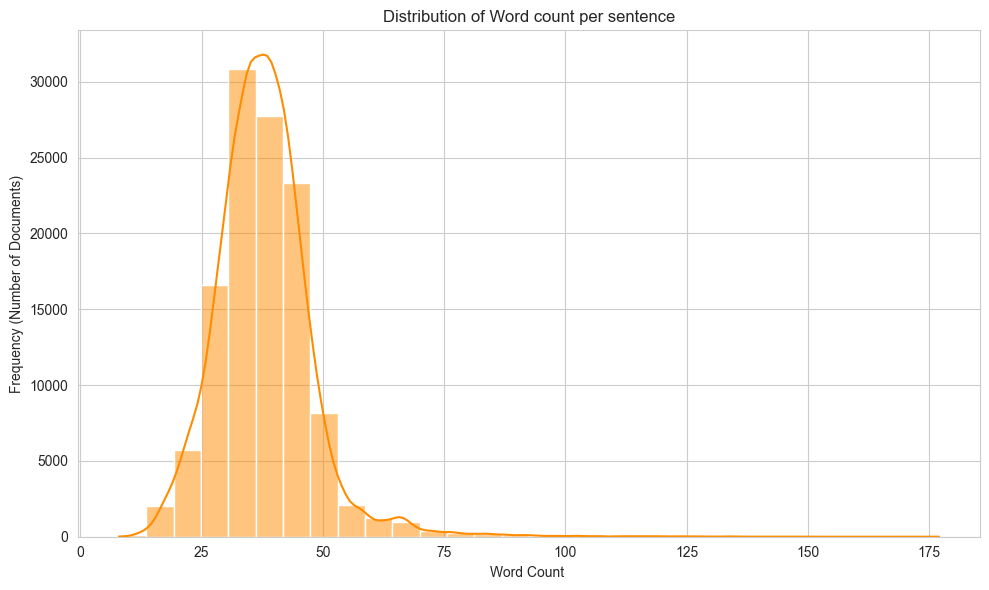

In [6]:
#Average word count in the dataset.

train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))
avg_word_count_train = train_df['word_count'].mean()
print(f"Average word count (train): {avg_word_count_train}")

plt.figure(figsize=(10,6))
sns.histplot(train_df['word_count'], bins=30, kde=True, color='darkorange')
plt.title("Distribution of Word count per sentence")
plt.xlabel("Word Count ")
plt.ylabel("Frequency (Number of Documents)")
plt.tight_layout()
plt.savefig("images/word_count_distribution.png")
plt.show()
plt.close()

In [24]:
#creating a corpus
corpus = ''
for i in train_df['text']:
    corpus += " " + i

corpus_list = corpus.split()

In [30]:
from collections import defaultdict

def calculate_ngram_probs(token_list:list[str], n: int, smoothing_k: float = 1.0): 
    
    if n < 1:
        raise ValueError("N must be 1 or greater")

    vocab = set(token_list)
    V = len(vocab)

    print(f"\n ----Calculating N={n} Probabilities----")
    print(f" Vocabulary Size (V): {V}")
    print(f"smoothing K: {smoothing_k}")

    if n==1:
        counts = defaultdict(int)
        total_tokens = len(token_list)

        for token in token_list:
            counts[(token,1)] += 1

        probabilities = defaultdict(float)
        denominator = total_tokens + (smoothing_k *V)
        for ngram,count in counts.items():
            probabilities[ngram] = (count + smoothing_k)/denominator

        return probabilities, counts

    ngram_counts = defaultdict(int)
    context_counts = defaultdict(int)

    for i in range(len(token_list)-n+1):
        ngram = tuple(token_list[i:i+n])
        context = tuple(token_list[i:i+n-1])
        
        ngram_counts[ngram] += 1
        context_counts[context] += 1

    probabilities = defaultdict(float)

    for ngram,count in ngram_counts.items():
        context = ngram[:-1]
        context_count = context_counts[context]
        denominator = context_count + (smoothing_k * V)
        probabilities[ngram] = (count + smoothing_k) / denominator

    return probabilities, ngram_counts, context_counts
        


 ----Calculating N=1 Probabilities----
 Vocabulary Size (V): 188110
smoothing K: 0

Generating plot...


C:\Users\moham\AppData\Local\Temp\ipykernel_68976\2283714252.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


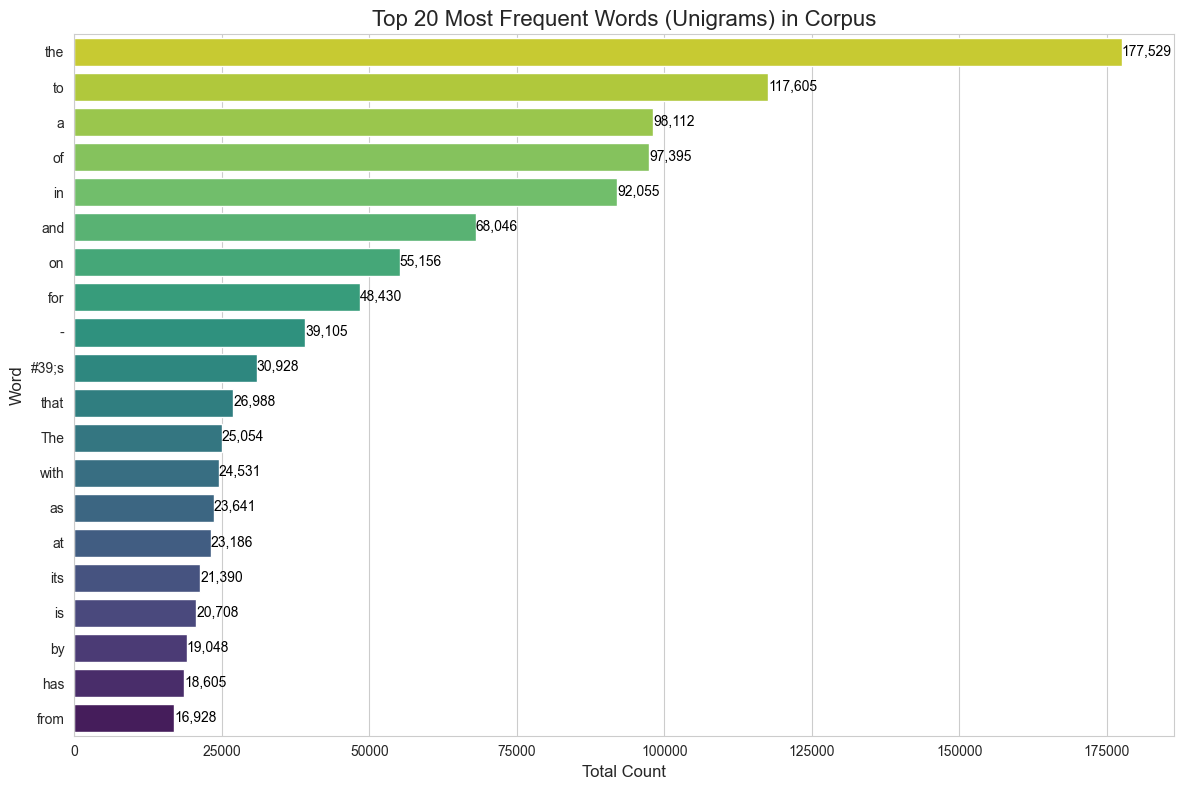

<Figure size 640x480 with 0 Axes>

In [32]:
unigram_probs, unigram_counts = calculate_ngram_probs(corpus_list, n=1, smoothing_k=0)

word_count_list = [
    (ngram[0], count) for ngram, count in unigram_counts.items()
]

word_count_list.sort(key=lambda item: item[1] , reverse=True)

top_20_words = word_count_list[:20]

top_20_df = pd.DataFrame(top_20_words, columns=['Word', 'Count'])

print("\nGenerating plot...")
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=top_20_df, 
    x='Count', 
    y='Word', 
    palette='viridis_r' # Use a reverse viridis color palette
)

plt.title('Top 20 Most Frequent Words (Unigrams) in Corpus', fontsize=16)
plt.xlabel('Total Count', fontsize=12)
plt.ylabel('Word', fontsize=12)

# Add count labels 
for index, row in top_20_df.iterrows():
    barplot.text(row.Count + 0.5,
                 index + 0.1,    
                 f'{row.Count:,}',
                 color='black', 
                 ha="left")

plt.tight_layout()
plt.show()
plt.savefig('images/top20words.png')


C:\Users\moham\AppData\Local\Temp\ipykernel_68976\3024765716.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


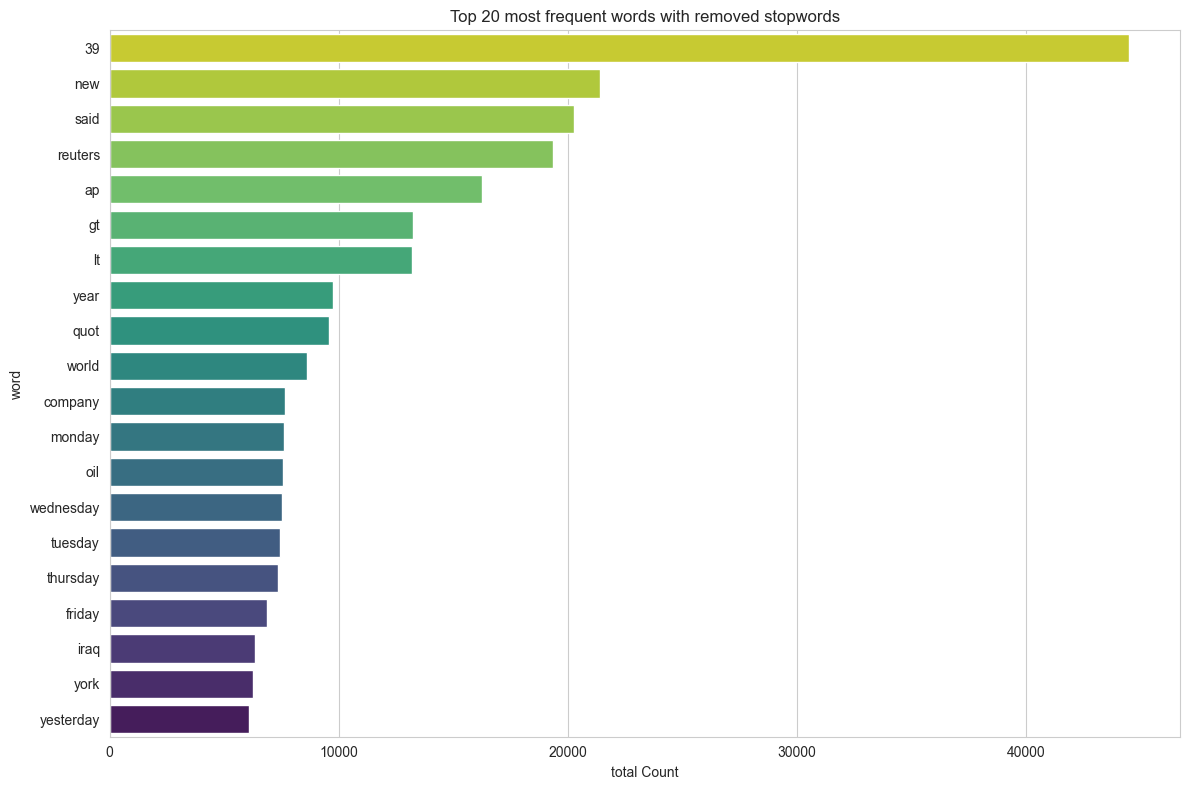

<Figure size 640x480 with 0 Axes>

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words = "english",
    ngram_range = (1,1)
)

word_count_matrix = vectorizer.fit_transform(train_df['text'])
total_counts = np.array(word_count_matrix.sum(axis=0)).flatten()

feature_names = vectorizer.get_feature_names_out()

word_counts_df = pd.DataFrame({
    "Word": feature_names,
    "Count": total_counts
})

word_counts_df = word_counts_df.sort_values(by="Count", ascending=False)

top_20_df_cleaned = word_counts_df.head(20)

plt.figure(figsize=(12,8))
sns.set_style('whitegrid')
barplot = sns.barplot(
    data=top_20_df_cleaned,
    x="Count",
    y = "Word",
    palette = "viridis_r"
)

plt.title("Top 20 most frequent words with removed stopwords")
plt.xlabel("total Count")
plt.ylabel("word")
# for index, row in top_20_df.iterrows():
#     barplot.text(row.Count + 0.1, # Position the text slightly off the bar
#                  index + 0.1,    # Align with the bar's y-position
#                  f'{row.Count:,}', # Format the count with a comma
#                  color='black', 
#                  ha="left")

plt.tight_layout()
plt.show()
plt.savefig('images/top20wordscleaned.png')

In [46]:
word_counts_df.to_csv('datasets/word_counts.csv')

### Visualizations:
The visualizations can help us understand the following :

- The Average word count per row or topic is 38 words.
- The most frequent words figure helps us know the most frequent words in the corpus, in our case the number '39' is the most frequent word may be it is some kind of score or point scored in a game, which is being repeated very often.

In [47]:
word_counts_df

,Word,Count
1314,39,44506
39634,new,21427
50065,said,20267
48666,reuters,19340
4977,ap,16276
...,...,...
45607,propped,1
20313,eroticism,1
45603,proposera,1
20314,erototoxins,1
